Importing libraries 

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("../data/processed/insurance_cleaned.csv")

# Create an in-memory SQLite database name will be insurance for simplicity

conn = sqlite3.connect(":memory:")
df.to_sql("insurance", conn, index=False, if_exists="replace")

1337

In [21]:
print([col for col in df.columns])

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [23]:
sample_query = "SELECT * FROM insurance LIMIT 100"
pd.read_sql(sample_query, conn)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
95,28,female,37.620,1,no,southeast,3766.88380
96,54,female,30.800,3,no,southwest,12105.32000
97,55,male,38.280,0,no,southeast,10226.28420
98,56,male,19.950,0,yes,northeast,22412.64850


# --------------------------------------------------------------

In [ ]:
# Q1: How much do medical charges differ between smokers and non-smokers?
query1 = """

SELECT smoker, ROUND(AVG(charges), 2) as avg_charges, COUNT(*) as members
FROM insurance
GROUP BY smoker
ORDER BY avg_charges DESC


"""
pd.read_sql(query1, conn)

,smoker,avg_charges,members
0,yes,32050.23,274
1,no,8440.66,1063


Smokers had average charges of $32,050 compared with $8,441 for non-smokers, or approximately 3.8 times higher. The dataset contained 274 smokers and 1,063 non-smokers.

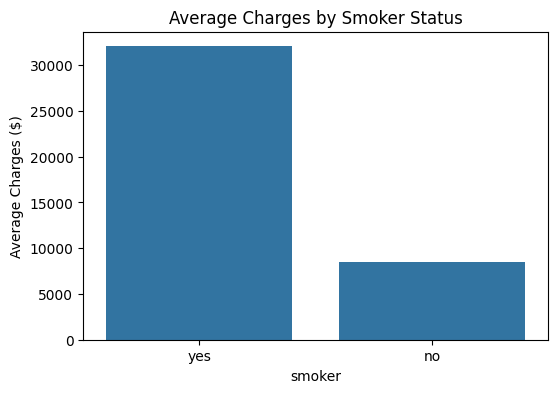

In [30]:
result1 = pd.read_sql(query1, conn)  # the smoker vs avg_charges query

plt.figure(figsize=(6,4))
sns.barplot(data=result1, x='smoker', y='avg_charges')
plt.title("Average Charges by Smoker Status")
plt.ylabel("Average Charges ($)")
plt.show()

In [11]:
# Q2 Which age groups have the highest average medical charges?

query2 = """

SELECT 
    CASE 
        WHEN age < 30 THEN 'Under 30'
        WHEN age BETWEEN 30 AND 50 THEN '30-50'
        WHEN age > 50 THEN 'Over 50'
    END AS age_group,
    ROUND(AVG(charges), 2) as avg_charges,
    COUNT(*) as members
FROM insurance
GROUP BY age_group
ORDER BY avg_charges DESC

"""
pd.read_sql(query2, conn)

,age_group,avg_charges,members
0,Over 50,18084.99,356
1,30-50,13253.93,565
2,Under 30,9200.62,416


Members over age 50 had the highest average medical charges at approximately $18,085, compared with $13,254 for ages 30–50 and $9,201 for members under 30. This suggests medical costs increase substantially with age in this dataset.

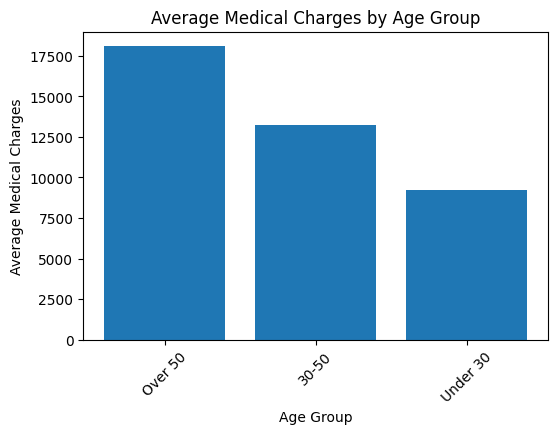

In [29]:
result2 = pd.read_sql(query2, conn) 

plt.figure(figsize=(6, 4))
plt.bar(result2['age_group'], result2['avg_charges'])
plt.xlabel('Age Group')
plt.ylabel('Average Medical Charges')
plt.title('Average Medical Charges by Age Group')
plt.xticks(rotation=45)
plt.show()

In [16]:
# Q3: How does BMI category relate to average medical charges?

query3 = """

SELECT 
    CASE 
        WHEN bmi < 18.5 THEN 'Underweight'
        WHEN bmi < 25 THEN 'Normal'
        WHEN bmi < 30 THEN 'Overweight'
        ELSE 'Obese'
    END AS bmi_category,
    ROUND(AVG(charges), 2) as avg_charges,
    COUNT(*) as members
FROM insurance
GROUP BY bmi_category
ORDER BY avg_charges DESC

"""
pd.read_sql(query3, conn)

,bmi_category,avg_charges,members
0,Obese,15572.04,706
1,Overweight,10987.51,386
2,Normal,10409.34,225
3,Underweight,8852.20,20


Members in the obese BMI category had the highest average medical charges at approximately $15,572, substantially above the other BMI groups. This suggests higher BMI is associated with increased healthcare costs in this dataset.

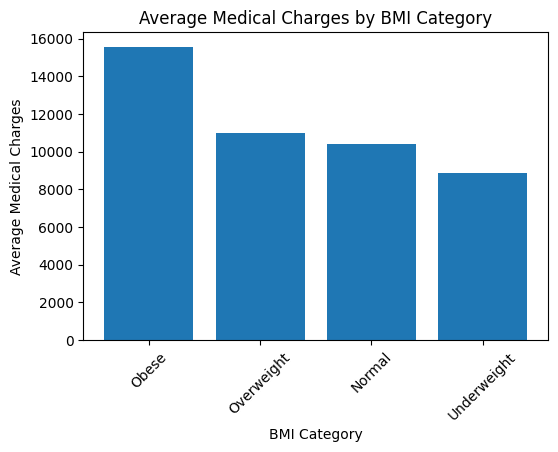

In [28]:
result3 = pd.read_sql(query3, conn) 

plt.figure(figsize=(6, 4))
plt.bar(result3['bmi_category'], result3['avg_charges'])
plt.xlabel('BMI Category')
plt.ylabel('Average Medical Charges')
plt.title('Average Medical Charges by BMI Category')
plt.xticks(rotation=45)
plt.show()

In [27]:
# Q4: Which region has the highest average medical charges, and how many members are in each region?
query4 = """


SELECT
    region,
    ROUND(AVG(charges), 2) AS avg_charges,
    COUNT(*) AS members
FROM insurance
GROUP BY region
ORDER BY avg_charges DESC

"""
result4 = pd.read_sql(query4, conn)
print(result4)

      region  avg_charges  members
0  southeast     14735.41      364
1  northeast     13406.38      324
2  northwest     12450.84      324
3  southwest     12346.94      325


The Southeast had the highest average medical charges at approximately $14,735, while the Southwest had the lowest at about $12,347. Member counts were fairly similar across regions, so the difference is less likely to be caused by one region having a much larger sample.

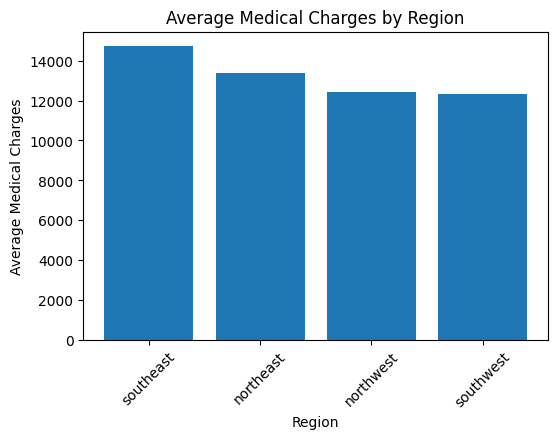

In [31]:
result4 = pd.read_sql(query4, conn)

plt.figure(figsize=(6, 4))
plt.bar(result4['region'], result4['avg_charges'])
plt.xlabel('Region')
plt.ylabel('Average Medical Charges')
plt.title('Average Medical Charges by Region')
plt.xticks(rotation=45)
plt.show()

In [32]:
# Q5: Which combination of age group, BMI category, and smoking status has the highest average medical charges?

q5 = """
SELECT
    CASE
        WHEN age < 30 THEN 'Under 30'
        WHEN age BETWEEN 30 AND 50 THEN '30-50'
        ELSE 'Over 50'
    END AS age_group,

    CASE
        WHEN bmi < 18.5 THEN 'Underweight'
        WHEN bmi < 25 THEN 'Normal'
        WHEN bmi < 30 THEN 'Overweight'
        ELSE 'Obese'
    END AS bmi_category,

    smoker,

    ROUND(AVG(charges), 2) AS avg_charges,
    COUNT(*) AS members

FROM insurance

GROUP BY age_group, bmi_category, smoker

HAVING COUNT(*) >= 10

ORDER BY avg_charges DESC
LIMIT 10
"""
result5 = pd.read_sql(q5, conn)
print(result5)

  age_group bmi_category smoker  avg_charges  members
0   Over 50        Obese    yes     47369.07       38
1     30-50        Obese    yes     41478.28       62
2  Under 30        Obese    yes     36760.68       45
3   Over 50   Overweight    yes     27877.12       15
4   Over 50       Normal    yes     24210.26       11
5     30-50   Overweight    yes     22908.67       36
6     30-50       Normal    yes     20108.15       24
7  Under 30   Overweight    yes     18340.25       23
8  Under 30       Normal    yes     16546.85       15
9   Over 50        Obese     no     13730.63      181


The highest-cost group was members over age 50 who were obese and smoked, with average medical charges of about $47,369. Obese smokers ages 30–50 were next at about $41,478, followed by obese smokers under 30 at about $36,761. This shows smoking status, obesity, and older age together are associated with the highest medical costs in this dataset.

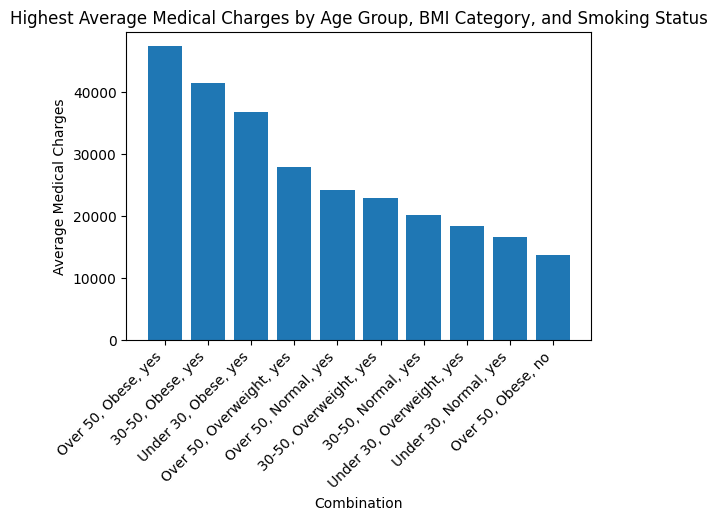

In [34]:
result5 = pd.read_sql(q5, conn)
plt.figure(figsize=(6, 4))
plt.bar(range(len(result5)), result5['avg_charges'])
plt.xlabel('Combination')
plt.ylabel('Average Medical Charges')
plt.title('Highest Average Medical Charges by Age Group, BMI Category, and Smoking Status')
plt.xticks(range(len(result5)), [f"{row['age_group']}, {row['bmi_category']}, {row['smoker']}" for _, row in result5.iterrows()], rotation=45, ha='right')
plt.show()